# Assignment 3: LLMs and Machine Learning

## Statement of AI use

I used Claude (claude.ai web interface) as a study aid throughout this assignment. I treated it as a tutor rather than a code generator: when I got stuck I asked for help with a specific part, then read through the result and made sure I could explain it before moving on.

For Task 0 Claude helped me debug a broken pydantic install that blocked the Ollama import. For Task 1 it helped me write the classification function and the post-processing step that extracts a clean label from the model's response. For Task 2 it helped with the JSON parsing fallback, and for 2c I used Claude itself as the browser based LLM to compare against gemma3:4b. For Task 3 Claude explained why to drop the `duration` column, why F1 is better than accuracy for imbalanced data, and the difference between cross validation and a single holdout split.

I ran every cell myself, interpreted the outputs, and wrote the discussion and conclusion sections in my own words based on the numbers I actually saw. I also went through a comprehension walkthrough of the code.

## Task 0: Setting up Ollama

In [1]:
import ollama
import pandas as pd
import json

print("All imports OK")
print("Available models:", [m.model for m in ollama.list().models])

All imports OK
Available models: ['gemma3:4b', 'gemma3:270m']


In [2]:
# Task 0b: Test the 270m model
response = ollama.chat(
    model='gemma3:270m',
    messages=[{'role': 'user', 'content': 'What is the capital of Finland? Answer in one word.'}]
)
print(response['message']['content'])

\



In [3]:
# Task 0c: Test the 4b model
response = ollama.chat(
    model='gemma3:4b',
    messages=[{'role': 'user', 'content': 'What is the capital of Finland? Answer in one word.'}]
)
print(response['message']['content'])

Helsinki


## Task 1: Text classification with Ollama

In [4]:
# Load the emails dataset
# The file is one headline per line; commas inside headlines confuse pandas default parser,
# so we read with no separator and treat each line as a single string.
emails = pd.read_csv('emails.csv', header=0, sep='\t', names=['headline'], engine='python')
display(emails)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


### Task 1a: Classification function

The function below takes a headline and a model name, sends a strict prompt to the model,
and returns only the classification label. The post-processing step (looking for the first
matching label in the response) is there because small models often ignore the "answer in
one word" instruction and add extra text.

In [5]:
# Task 1a: Function for classifying emails as spam, work, or unknown
def classify_email(headline, model='gemma3:270m'):
    """
    Classify a single email headline as 'spam', 'work', or 'unknown'.
    Returns just the label string.
    """
    # Strict prompt - repeat the constraint twice so the model is more likely to obey
    prompt = (
        "Classify the following email headline into exactly one of these "
        "three categories: spam, work, or unknown. "
        "Respond with ONLY the single word (spam, work, or unknown) "
        "and nothing else.\n\n"
        f"Headline: {headline}"
    )
    
    # Send to the model
    response = ollama.chat(
        model=model,
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    # Clean up the raw output (strip whitespace, lowercase)
    raw = response['message']['content'].strip().lower()
    
    # Extract the first valid label that appears in the response
    # This handles cases where the model adds extra words despite the instruction
    for label in ['spam', 'work', 'unknown']:
        if label in raw:
            return label
    
    # If nothing matches, return the raw output so we can see what the model actually said
    return raw

### Task 1b: Classification with gemma3:270m (small model)

In [6]:
# Task 1b: Run all 12 headlines through the small 270m model
# .apply() calls classify_email() on each row's headline
emails_270m = emails.copy()
emails_270m['classification_270m'] = emails_270m['headline'].apply(
    lambda h: classify_email(h, model='gemma3:270m')
)

display(emails_270m)

,headline,classification_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


### Task 1c: Classification with gemma3:4b (larger model)

In [7]:
# Task 1c: Run the same 12 headlines through the larger 4b model
# This is noticeably slower than the 270m run because the model is ~15x bigger,
# but the output should be much more sensible.
emails_4b = emails.copy()
emails_4b['classification_4b'] = emails_4b['headline'].apply(
    lambda h: classify_email(h, model='gemma3:4b')
)

display(emails_4b)

,headline,classification_4b
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",work
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,work
9,Following up,work


### Comparison: gemma3:270m vs gemma3:4b

The two models gave very different results.

The **270m model** labeled every single headline as "spam", including the obvious work emails. It basically ignored the prompt and gave the same answer to everything. So it got 4 out of 12 right, and only because the four real spam emails happened to match its default answer.

The **4b model** worked much better. It correctly classified all 4 spam and all 4 work emails. For the 4 vague headlines it never used "unknown" and instead guessed work or spam, which is wrong but at least the choices are reasonable.

The takeaway is that model size matters. The 270m is too small to follow the instructions properly. The 4b model handles clear cases well but still misses the idea that some headlines should be classified as "unknown".

### Task 1d: Repeated runs to test consistency

LLM outputs can vary between runs even with the same input, due to randomness in token
sampling. Here we run both models 3 times each on the full email dataset and compare
how stable each model's classifications are across runs.

In [8]:
# Task 1d: Run both models 3 times each and compare run-to-run consistency

# Start with the original headlines
results = emails.copy()

# Run gemma3:270m three times
print("Running gemma3:270m three times...")
for i in range(1, 4):
    col_name = f'270m_run{i}'
    results[col_name] = results['headline'].apply(
        lambda h: classify_email(h, model='gemma3:270m')
    )
    print(f"  Run {i} done")

# Run gemma3:4b three times
print("\nRunning gemma3:4b three times...")
for i in range(1, 4):
    col_name = f'4b_run{i}'
    results[col_name] = results['headline'].apply(
        lambda h: classify_email(h, model='gemma3:4b')
    )
    print(f"  Run {i} done")

display(results)

Running gemma3:270m three times...
  Run 1 done
  Run 2 done
  Run 3 done

Running gemma3:4b three times...
  Run 1 done
  Run 2 done
  Run 3 done


,headline,270m_run1,270m_run2,270m_run3,4b_run1,4b_run2,4b_run3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,spam,spam,work,work,work
5,"Q3 budget report attached, please review by Fr...",spam,spam,spam,work,work,work
6,Reminder: Annual performance review scheduled ...,spam,spam,spam,work,work,work
7,"Updated draft of the manuscript, comments welcome",spam,spam,spam,work,work,work
8,Quick question about last week,spam,spam,spam,work,work,work
9,Following up,spam,spam,spam,work,work,work


### Comparison of run-to-run variation

Both models gave the exact same results across all three runs. There was no variation at all.

The **270m model** labeled every headline as "spam" in all three runs. So it is consistent but consistently wrong on most of them.

The **4b model** also gave the same answer for every headline across runs. For example "Meeting agenda" was "work" all three times, and "Are you available?" was "spam" all three times.

I expected some variation since LLMs use temperature when sampling tokens, but probably the prompt was strict enough and the model was confident enough that the same word came out every time. With only three valid choices ("spam", "work", "unknown") there is not much room for the output to drift.

It is worth noting that consistent does not mean accurate. The 270m being stable is actually worse than a model that sometimes gets things right and sometimes wrong.

## Task 2: Sentiment analysis with Ollama

Here we classify financial news headlines two ways at once: by topic (earnings, mergers, regulation, macroeconomics) and by sentiment (positive, negative, neutral).

The function returns the result as JSON so we can pull both values from a single model call. Then we compare the local model's output against a browser based LLM on the same headlines.

In [9]:
# Load the news dataset (same trick as before, sep='\t' so commas in headlines are not split)
news = pd.read_csv('news.csv', header=0, sep='\t', names=['headline'], engine='python')
display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


### Task 2a: Classification function with JSON output

The function asks the model to return a JSON object with two keys, then parses it.
We use Python's json module to convert the model's text response into a dict, with
fallback handling in case the model returns text around the JSON or malformed JSON.

In [10]:
# Task 2a: Function that returns topic + sentiment as JSON
import re

def classify_news(headline, model='gemma3:4b'):
    """
    Classify a financial news headline by topic and sentiment.
    Returns a dict with 'topic' and 'sentiment' keys.
    """
    # Strict prompt that asks for JSON output and lists the allowed values
    prompt = (
        "Classify the following financial news headline. Return ONLY a JSON object "
        "with two fields:\n"
        '  - "topic": one of "earnings", "mergers", "regulation", "macroeconomics"\n'
        '  - "sentiment": one of "positive", "negative", "neutral"\n\n'
        "Do not include any explanation, only the JSON object.\n\n"
        f"Headline: {headline}"
    )
    
    response = ollama.chat(
        model=model,
        messages=[{'role': 'user', 'content': prompt}]
    )
    raw = response['message']['content'].strip()
    
    # Try to parse the response directly as JSON first
    try:
        parsed = json.loads(raw)
        return {
            'topic': parsed.get('topic', 'parse_error').lower(),
            'sentiment': parsed.get('sentiment', 'parse_error').lower()
        }
    except json.JSONDecodeError:
        # Fallback: model wrapped the JSON in extra text or used markdown fences
        # Extract anything that looks like {...}
        match = re.search(r'\{.*?\}', raw, re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group())
                return {
                    'topic': parsed.get('topic', 'parse_error').lower(),
                    'sentiment': parsed.get('sentiment', 'parse_error').lower()
                }
            except json.JSONDecodeError:
                pass
        # If everything fails, return the raw string for debugging
        return {'topic': 'parse_error', 'sentiment': raw[:50]}

### Quick test: run the function on one headline to confirm it works

In [11]:
# Quick test
test_headline = news['headline'].iloc[0]
test_result = classify_news(test_headline, model='gemma3:4b')

print(f"Headline: {test_headline}")
print(f"Result: {test_result}")

Headline: Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
Result: {'topic': 'earnings', 'sentiment': 'positive'}


### Task 2b: Apply gemma3:4b to all news headlines

In [12]:
# Task 2b: Run the classifier on every news headline using gemma3:4b
news_classified = news.copy()

# .apply() returns one dict per row, we expand that into two columns
classifications = news_classified['headline'].apply(
    lambda h: classify_news(h, model='gemma3:4b')
)
news_classified['topic'] = classifications.apply(lambda d: d['topic'])
news_classified['sentiment'] = classifications.apply(lambda d: d['sentiment'])

display(news_classified)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 2c: Comparison with a browser based LLM

I gave the same 10 headlines to Claude (Anthropic's web interface) using the same prompt. Here are Claude's results:

| # | Headline | Topic | Sentiment |
|---|----------|-------|-----------|
| 0 | Nordion beats Q1 earnings estimates | earnings | positive |
| 1 | Helvora misses earnings forecast | earnings | negative |
| 2 | Aurelis Bank reports steady profit | earnings | neutral |
| 3 | Veridyne to acquire Trantec | mergers | positive |
| 4 | Regulators block merger | mergers | negative |
| 5 | Kestrel merger talks with Aldenfeld | mergers | neutral |
| 6 | EU AI Act rules raise costs | regulation | negative |
| 7 | FSA grants Norvik expanded licence | regulation | positive |
| 8 | Eurozone inflation cools, easing pressure on Drava | macroeconomics | positive |
| 9 | Rising rates weigh on Tessaro Real Estate | macroeconomics | negative |

#### Comparison

The two models agreed on 6 out of 10 headlines and disagreed on 4. In every disagreement I think Claude's answer is the better one.

| # | Headline | gemma3:4b | Claude |
|---|----------|-----------|--------|
| 2 | Aurelis steady profit, in line with expectations | positive | neutral |
| 3 | Veridyne acquires Trantec in 4.2bn deal | neutral | positive |
| 7 | FSA grants Norvik expanded licence | neutral | positive |
| 8 | Eurozone inflation cools, easing pressure on Drava | neutral | positive |

The pattern is that gemma3:4b kept defaulting to "neutral" on headlines where the sentiment was implied rather than directly stated. Phrases like "easing pressure", "expanded licence" and "to acquire" all imply something positive but don't say it outright, and the smaller model missed that.

Claude is more accurate overall. This makes sense because Claude is a much bigger model and can pick up on implicit meaning better. The 4b model is fine for obvious cases but the larger model handles the subtle ones.

## Task 3: Supervised machine learning on the Bank Marketing dataset

The Bank Marketing dataset comes from the UCI repository. It contains data from phone marketing campaigns by a Portuguese bank. Each row is one customer call and the goal is to predict whether the customer subscribed to a term deposit (column `y`, yes or no).

This is a binary classification task with imbalanced classes since most customers do not subscribe.

Subparts:
* 3a: Exploratory data analysis
* 3b: Preprocessing
* 3c: Three classifiers with hyperparameter tuning
* 3d: Train/validation/test split versus cross validation
* 3e: Final evaluation

### Task 3a: Exploratory Data Analysis

Before building any models I want to understand the data: shape, variable types, missing values, target distribution, and what the main features look like.

In [13]:
# Load the bank marketing dataset
# Note: the file uses semicolons as separators, not commas
bank = pd.read_csv('bank-additional.csv', sep=';')

# Basic shape and structure
print("Shape (rows, columns):", bank.shape)
print()
print("First 5 rows:")
display(bank.head())

Shape (rows, columns): (4119, 21)

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


#### Column types and missing values

The dataset uses 'unknown' as a placeholder string in some categorical columns instead of NaN, so I check both.

In [14]:
# Data types
print("Data types:")
print(bank.dtypes)
print()

# Standard missing value check (looking for actual NaN entries)
print("NaN counts per column:")
print(bank.isnull().sum())
print()

# The dataset uses 'unknown' as a placeholder in categorical columns
# Count how often 'unknown' appears in each column
print("'unknown' counts per column:")
unknown_counts = (bank == 'unknown').sum()
print(unknown_counts[unknown_counts > 0])

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

NaN counts per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y   

#### Target variable distribution

The target `y` is whether the customer subscribed. I expect strong imbalance toward "no", which matters because plain accuracy will be misleading.

Target value counts:
y
no     3668
yes     451
Name: count, dtype: int64

Target proportions:
y
no     0.891
yes    0.109
Name: proportion, dtype: float64


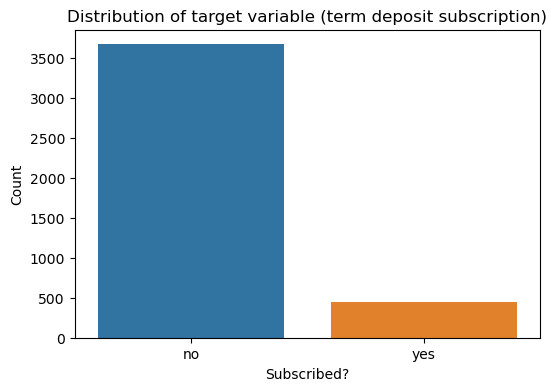

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show the counts and proportions of the target
print("Target value counts:")
print(bank['y'].value_counts())
print()
print("Target proportions:")
print(bank['y'].value_counts(normalize=True).round(3))

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=bank, x='y', order=['no', 'yes'])
plt.title('Distribution of target variable (term deposit subscription)')
plt.xlabel('Subscribed?')
plt.ylabel('Count')
plt.show()

#### Numerical feature distributions

We look at the spread of the numerical features to see if any need scaling, have heavy
outliers, or behave oddly. Common things to look for: features measured on very different
scales (which would dominate distance based models if not scaled), and features with
suspicious values (for example, the `pdays` column uses 999 to mean "not previously
contacted").

In [16]:
# Summary statistics for the numerical columns
numerical_cols = bank.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", numerical_cols)
print()
print("Summary statistics:")
display(bank[numerical_cols].describe().round(2))

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00
mean,40.11,256.79,2.54,960.42,0.19,0.08,93.58,-40.50,3.62,5166.48
std,10.31,254.70,2.57,191.92,0.54,1.56,0.58,4.59,1.73,73.67
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60
25%,32.00,103.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.33,5099.10
50%,38.00,181.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,317.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,88.00,3643.00,35.00,999.00,6.00,1.40,94.77,-26.90,5.04,5228.10


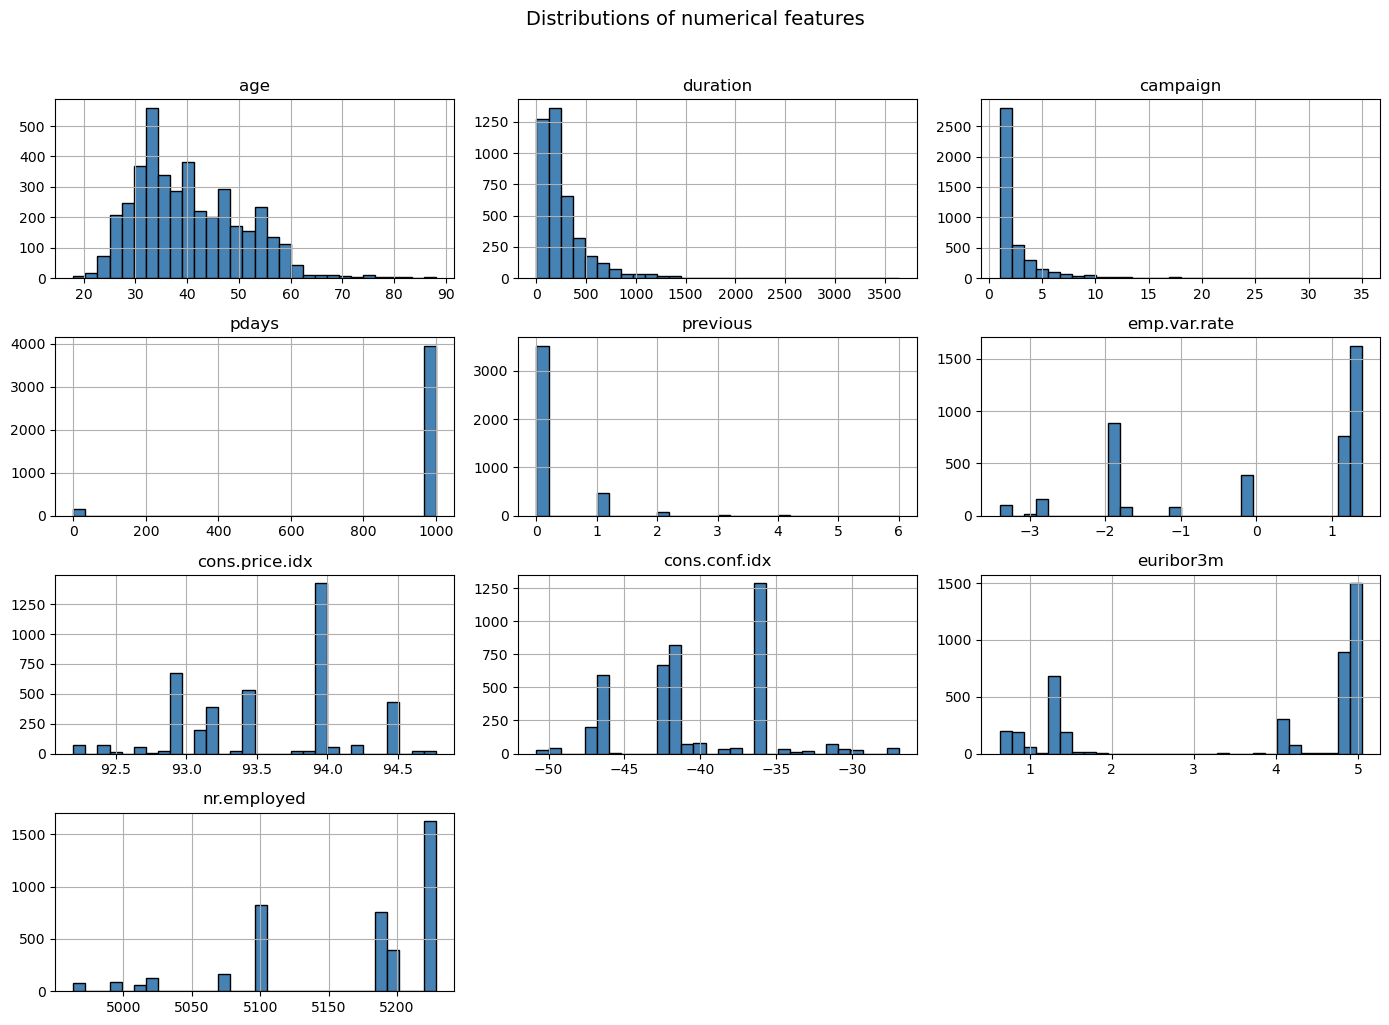

In [17]:
# Plot histograms for all numerical features at once
bank[numerical_cols].hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distributions of numerical features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Categorical features and the target

I want to see which categories have the highest subscription rates, since those will be useful signals for the model.

In [18]:
# List the categorical columns (excluding the target itself)
categorical_cols = bank.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')
print("Categorical columns:", categorical_cols)
print()

# Show subscription rate (% of "yes") for each category in each categorical feature
# Just print the most informative ones to keep the output manageable
key_cats = ['job', 'marital', 'education', 'contact', 'poutcome']
for col in key_cats:
    print(f"\nSubscription rate by {col}:")
    rate = bank.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
    print(rate.round(3))

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


Subscription rate by job:
job
student          0.232
retired          0.229
unemployed       0.171
admin.           0.131
technician       0.116
unknown          0.103
housemaid        0.100
management       0.093
services         0.089
self-employed    0.082
blue-collar      0.069
entrepreneur     0.054
Name: y, dtype: float64

Subscription rate by marital:
marital
single      0.134
married     0.100
divorced    0.096
unknown     0.091
Name: y, dtype: float64

Subscription rate by education:
education
unknown                0.156
university.degree      0.131
professional.course    0.121
high.school            0.105
basic.4y               0.089
basic.9y               0.075
basic.6y               0.075
illiterate             0.000
Name: y, dtype: float64

Subscription rate by contact:
contact
cellular     0.141
telephone    0.052
Name: y, dtype: float64

Su

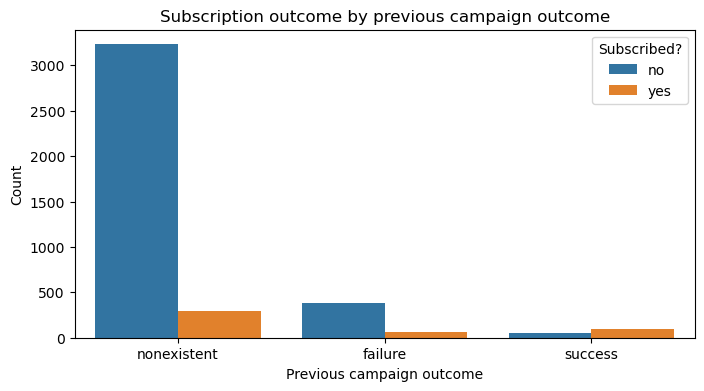

In [19]:
# Visualize the relationship between previous campaign outcome and subscription
# poutcome is one of the strongest predictors in this dataset
plt.figure(figsize=(8, 4))
sns.countplot(data=bank, x='poutcome', hue='y', order=['nonexistent', 'failure', 'success'])
plt.title('Subscription outcome by previous campaign outcome')
plt.xlabel('Previous campaign outcome')
plt.ylabel('Count')
plt.legend(title='Subscribed?')
plt.show()

#### EDA summary

Main takeaways:
* Around 4,100 rows and 21 columns, mix of numerical and categorical features.
* Target is heavily imbalanced (89% no, 11% yes), so accuracy alone will be misleading. F1 and ROC AUC make more sense.
* Several categorical columns use 'unknown' instead of NaN. I will treat 'unknown' as just another category in one hot encoding.
* Numerical features are on very different scales (age, employment indicators, euribor rate), so scaling is needed for distance based and linear models.
* `pdays = 999` means the customer was not previously contacted. I will recode this into a binary flag plus the actual days value.
* `duration` is highly predictive but I will drop it before modelling because the call duration is only known after the call has been made, so using it would be data leakage.
* `poutcome = success` is the strongest signal in the dataset. Customers who subscribed in a previous campaign are 7× more likely to subscribe again.

### Task 3b: Preprocessing

Steps:
1. **Drop `duration`** since it causes leakage (only known after the call).
2. **Recode `pdays`** by splitting it into a binary `was_contacted_before` flag plus the actual days value (zero if never contacted).
3. **Encode the target** from yes/no into 1/0.
4. **One hot encode categorical features**, keeping 'unknown' as its own category.
5. **Scale numerical features** to mean 0, std 1 so they are comparable.
6. **Train/test split** with 20% held out, stratified to keep the class balance.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop the leaky 'duration' column
bank_proc = bank.drop(columns=['duration']).copy()

# 2. Recode pdays: 999 means "not previously contacted"
bank_proc['was_contacted_before'] = (bank_proc['pdays'] != 999).astype(int)
bank_proc['pdays'] = bank_proc['pdays'].replace(999, 0)

# 3. Encode the target (yes -> 1, no -> 0)
bank_proc['y'] = (bank_proc['y'] == 'yes').astype(int)

# 4. One hot encode all categorical features
# pandas get_dummies handles this and keeps 'unknown' as just another category
categorical_cols = bank_proc.select_dtypes(include=['object']).columns.tolist()
bank_encoded = pd.get_dummies(bank_proc, columns=categorical_cols, drop_first=False)

# Convert any remaining bool columns from get_dummies into integers
bool_cols = bank_encoded.select_dtypes(include=['bool']).columns
bank_encoded[bool_cols] = bank_encoded[bool_cols].astype(int)

print("Shape after preprocessing:", bank_encoded.shape)
print("Number of features after one hot encoding:", bank_encoded.shape[1] - 1)

# Separate features (X) and target (y)
X = bank_encoded.drop(columns=['y'])
y = bank_encoded['y']

# 5. Train/test split, stratified on the target so class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining set:", X_train.shape, "  Target balance:", round(y_train.mean(), 3))
print("Test set:    ", X_test.shape, "  Target balance:", round(y_test.mean(), 3))

# 6. Scale numerical features (fit only on train to avoid leakage)
# We scale every column since the one-hot columns are already 0/1 and won't change much
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),  # Use transform, not fit_transform, on the test set
    columns=X_test.columns,
    index=X_test.index
)

print("\nPreprocessing complete. Scaled feature shapes:")
print("  X_train_scaled:", X_train_scaled.shape)
print("  X_test_scaled: ", X_test_scaled.shape)

Shape after preprocessing: (4119, 64)
Number of features after one hot encoding: 63

Training set: (3295, 63)   Target balance: 0.11
Test set:     (824, 63)   Target balance: 0.109

Preprocessing complete. Scaled feature shapes:
  X_train_scaled: (3295, 63)
  X_test_scaled:  (824, 63)


In [21]:
# Quick sanity check on the preprocessed data
print("First 3 rows of scaled training features (a few columns):")
display(X_train_scaled[['age', 'campaign', 'previous', 'pdays', 'was_contacted_before']].head(3).round(3))

print("\nMean of each scaled column should be ~0:")
print(X_train_scaled[['age', 'campaign', 'previous']].mean().round(3))

First 3 rows of scaled training features (a few columns):


,age,campaign,previous,pdays,was_contacted_before
2782,0.754,0.191,-0.363,-0.172,-0.207
2547,-0.596,-0.202,1.426,-0.172,-0.207
2994,0.657,-0.596,-0.363,-0.172,-0.207



Mean of each scaled column should be ~0:
age        -0.0
campaign    0.0
previous   -0.0
dtype: float64


### Task 3c: Three classifiers with hyperparameter tuning

This is binary classification (subscribe yes or no). I picked three models from different families so the comparison covers linear, ensemble, and boosting approaches:

1. **Logistic Regression**  a fast linear baseline. Good for one hot encoded features and easy to interpret. Useful to see if the more complex models are actually adding anything.
2. **Random Forest** an ensemble of decision trees. Captures non linear patterns and feature interactions, robust on tabular data.
3. **Gradient Boosting** trees built sequentially, each correcting the previous one's mistakes. Usually the best on tabular data but slower to train.

For tuning I use `GridSearchCV` with 5 fold stratified cross validation, optimising **F1 score** instead of accuracy. The dataset is 89% "no", so accuracy would reward a model that just predicts "no" for everyone.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# 5 fold stratified cross validation, used by GridSearchCV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
# Model 1: Logistic Regression
# Tuned hyperparameters:
#   - C: inverse of regularisation strength (smaller C = more regularisation)
#   - penalty: type of regularisation (L1 promotes sparsity, L2 shrinks all coefficients)
#   - class_weight: 'balanced' tells the model to weight the minority class more heavily

lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced']
}

lr_search = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)
lr_search.fit(X_train_scaled, y_train)

print("Logistic Regression")
print("  Best parameters:", lr_search.best_params_)
print("  Best CV F1 score:", round(lr_search.best_score_, 4))

Logistic Regression
  Best parameters: {'C': 10.0, 'class_weight': 'balanced', 'penalty': 'l2'}
  Best CV F1 score: 0.4187


In [24]:
# Model 2: Random Forest
# Tuned hyperparameters:
#   - n_estimators: number of trees in the forest
#   - max_depth: max depth of each tree (prevents overfitting)
#   - min_samples_split: min samples needed to split an internal node
#   - class_weight: weight the minority class more heavily

rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)

print("Random Forest")
print("  Best parameters:", rf_search.best_params_)
print("  Best CV F1 score:", round(rf_search.best_score_, 4))

Random Forest
  Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
  Best CV F1 score: 0.4751


In [25]:
# Model 3: Gradient Boosting
# Tuned hyperparameters:
#   - n_estimators: number of boosting rounds
#   - learning_rate: step size shrinkage (smaller = more conservative)
#   - max_depth: depth of individual trees (typically shallow for boosting)
#   - subsample: fraction of samples used per tree (adds randomness, reduces overfitting)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)
gb_search.fit(X_train_scaled, y_train)

print("Gradient Boosting")
print("  Best parameters:", gb_search.best_params_)
print("  Best CV F1 score:", round(gb_search.best_score_, 4))

Gradient Boosting
  Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
  Best CV F1 score: 0.3793


In [26]:
# Save the best estimators for use in 3d and 3e
best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

# Quick comparison of best CV F1 scores
print("Best cross validated F1 scores from GridSearchCV:")
print(f"  Logistic Regression : {lr_search.best_score_:.4f}")
print(f"  Random Forest       : {rf_search.best_score_:.4f}")
print(f"  Gradient Boosting   : {gb_search.best_score_:.4f}")

Best cross validated F1 scores from GridSearchCV:
  Logistic Regression : 0.4187
  Random Forest       : 0.4751
  Gradient Boosting   : 0.3793


### Task 3d: Train/validation/test split versus cross validation

So far I used 5 fold cross validation. Here I compare it against a single holdout: split off 20% of the training set as a validation set, fit each best model on the remaining 80%, and check F1 on the validation set. Then compare those numbers against the CV F1 scores from 3c.

I expect the single holdout to be noisier than 5 fold CV, especially since the validation set will only be ~660 rows.

In [27]:
# Split the training set into sub-train and validation (still stratified)
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Sub-train set:", X_subtrain.shape, "  Target balance:", round(y_subtrain.mean(), 3))
print("Validation set:", X_val.shape, "  Target balance:", round(y_val.mean(), 3))

Sub-train set: (2636, 63)   Target balance: 0.11
Validation set: (659, 63)   Target balance: 0.109


In [28]:
# Re-fit each best model on the sub-train portion only and evaluate on validation
# We use the best hyperparameters found earlier for each model

models_to_compare = {
    'Logistic Regression': LogisticRegression(**lr_search.best_params_, solver='liblinear', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(**gb_search.best_params_, random_state=42),
}

holdout_results = {}
for name, model in models_to_compare.items():
    model.fit(X_subtrain, y_subtrain)
    val_preds = model.predict(X_val)
    holdout_f1 = f1_score(y_val, val_preds)
    holdout_results[name] = holdout_f1
    print(f"{name} holdout F1 on validation set: {holdout_f1:.4f}")

Logistic Regression holdout F1 on validation set: 0.4839
Random Forest holdout F1 on validation set: 0.5113
Gradient Boosting holdout F1 on validation set: 0.3960


In [29]:
# Build a comparison DataFrame
comparison = pd.DataFrame({
    'CV F1 (5 fold, from 3c)': [
        lr_search.best_score_,
        rf_search.best_score_,
        gb_search.best_score_
    ],
    'Holdout F1 (single split)': [
        holdout_results['Logistic Regression'],
        holdout_results['Random Forest'],
        holdout_results['Gradient Boosting']
    ]
}, index=['Logistic Regression', 'Random Forest', 'Gradient Boosting']).round(4)

comparison['Difference'] = (comparison['Holdout F1 (single split)']
                            - comparison['CV F1 (5 fold, from 3c)']).round(4)

display(comparison)

,"CV F1 (5 fold, from 3c)",Holdout F1 (single split),Difference
Logistic Regression,0.4187,0.4839,0.0652
Random Forest,0.4751,0.5113,0.0362
Gradient Boosting,0.3793,0.3960,0.0167


#### Discussion: which approach performs better?

Both methods try to estimate the same thing (out of sample performance) but with different reliability:

* **Single holdout** uses just one validation fold of about 660 rows. The score depends heavily on which rows happen to land there. A different random seed could shift it by several points.
* **5 fold CV** averages over 5 different folds, so it is more stable and uses the data more efficiently.

In the table all three holdout F1 scores are higher than the CV F1 scores, but by very different amounts (+6.5 for LR, +3.6 for RF, +1.7 for GB). The fact that the gap varies so much per model is exactly the kind of noise we expect from a single split. The CV estimate is more trustworthy.

Random Forest comes out on top under both methods, which gives extra confidence that it really is the best of the three. I use CV for tuning and selection and reserve the held out test set for the final unbiased check in Task 3e.

### Task 3e: Final evaluation on the test set

I retrain each best model on the full training set (using the hyperparameters from 3c) and evaluate on the held out test set, which has not been used until now.

Five metrics:
* **Accuracy**  overall correct rate. Misleading here because of the class imbalance, included for completeness.
* **Precision**  of those predicted "yes", how many actually subscribed. High precision = few false positives, useful when calling has a cost.
* **Recall**  of actual subscribers, how many did we catch. High recall = fewer missed opportunities.
* **F1**  harmonic mean of precision and recall. The single balanced number, and what we tuned on.
* **ROC AUC**  threshold independent measure of how well the model separates the two classes.

For imbalanced data F1 and ROC AUC are the most informative metrics.

In [30]:
# Refit each best model on the full training set
final_models = {
    'Logistic Regression': LogisticRegression(**lr_search.best_params_, solver='liblinear', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(**gb_search.best_params_, random_state=42),
}

# Train each on the full training data and evaluate on the test set
test_results = []
for name, model in final_models.items():
    model.fit(X_train_scaled, y_train)
    
    # Predictions and probabilities on the test set
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1
    
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

# Display as a clean DataFrame
results_df = pd.DataFrame(test_results).set_index('Model').round(4)
display(results_df)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.8350,0.3467,0.5778,0.4333,0.7543
Random Forest,0.8871,0.4815,0.4333,0.4561,0.7580
Gradient Boosting,0.8944,0.5385,0.2333,0.3256,0.7414


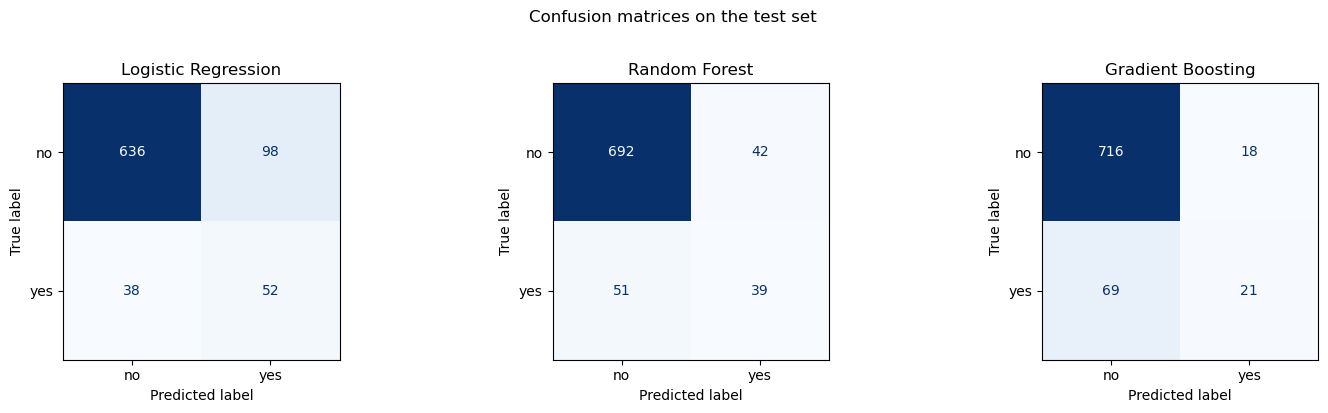

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrices for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion matrices on the test set', y=1.02)
plt.tight_layout()
plt.show()

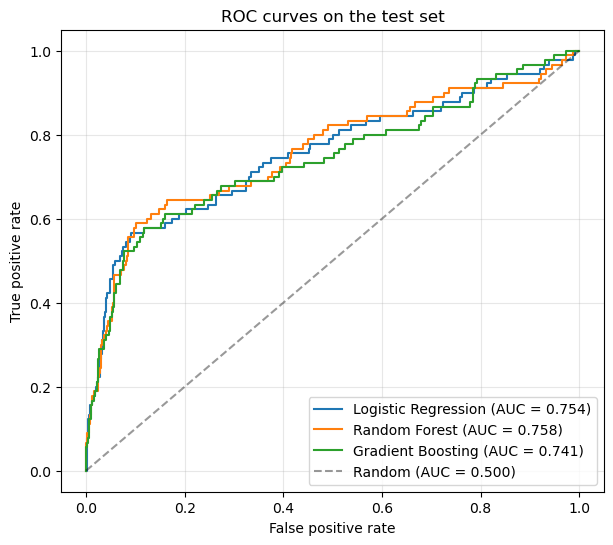

In [32]:
from sklearn.metrics import roc_curve

# Plot ROC curves for all three models on one chart
plt.figure(figsize=(7, 6))

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Diagonal reference line for random classifier
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves on the test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [33]:
# Detailed classification report for the best model (Random Forest based on CV F1)
print("Classification report for Random Forest on the test set:")
print()
y_pred_rf = final_models['Random Forest'].predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf, target_names=['no (did not subscribe)', 'yes (subscribed)']))

Classification report for Random Forest on the test set:

                        precision    recall  f1-score   support

no (did not subscribe)       0.93      0.94      0.94       734
      yes (subscribed)       0.48      0.43      0.46        90

              accuracy                           0.89       824
             macro avg       0.71      0.69      0.70       824
          weighted avg       0.88      0.89      0.88       824



#### Final recommendation

Based on the test set results, my recommended model is **Random Forest**.

**Why Random Forest:**
* Highest **F1 (0.456)**  best balance of precision and recall on the minority class.
* Highest **ROC AUC (0.758)**  best at separating subscribers from non-subscribers.
* Most consistent winner across all three evaluation strategies (CV in 3c, holdout in 3d, test set in 3e).

**Why not the others:**
* **Logistic Regression** has the highest recall (57.8%) but only 34.7% precision, meaning two thirds of customers it flags as likely subscribers will actually say no. It would be a fine choice if the bank only cares about catching subscribers and call costs are low. It is also the most interpretable model.
* **Gradient Boosting** has the highest accuracy (89.4%) and precision (53.9%) but its recall collapses to 23.3%  it misses three out of four real subscribers. The likely reason is that scikit-learn's `GradientBoostingClassifier` does not support `class_weight='balanced'`, so it had no way to compensate for the heavy class imbalance during training.

For the bank's marketing team, Random Forest gives the most useful predictions overall: it catches a reasonable share of actual subscribers without flooding the list with false positives.